---
# **Кластеризация сигналов сцинтилляционного детектора**
---

**Задача:** автоматически разделить 23 479 осциллограмм на три кластера:
- **Класс 0** — один тип частиц (гамма-кванты или нейтроны)
- **Класс 1** — другой тип частиц
- **Класс 2** — аномальные / нераспознанные сигналы

Работа выполнена в парадигме **unsupervised learning**: размеченных данных нет,
только сырые осциллограммы. Из каждого сигнала извлекаются физически
мотивированные признаки (Feature Engineering), после чего сравниваются несколько
алгоритмов кластеризации, выбирается лучший, формируется submission.

**Воспроизводимость:** фиксируем `SEED = 42`.


### **Подготовил:**

### **ФИО: Жуков Тимофей Владимирович**

### **Группа: М25-555**

---
### **0. Импорт библиотек**
---

In [57]:
!pip install hdbscan

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats, signal as scipy_signal
from scipy.integrate import trapezoid
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_selection import VarianceThreshold

import umap.umap_ as umap
import os
import hdbscan

In [63]:
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

HAS_HDBSCAN = True
SEED = 42
np.random.seed(SEED)

DATA_PATH = "./Run200_Wave_0_1.txt"
SUBMIT_DIR = "submissions"
os.makedirs(SUBMIT_DIR, exist_ok=True)

---
### **1. Загрузка датасета**
---


**Загрузим данные и сразу отделим метаданные (первые 4 поля) от основных данных для обучения**

In [4]:
raw = pd.read_csv(DATA_PATH, sep=' ', header=None, skipinitialspace=True)
raw = raw.dropna(axis=1, how='all')

meta = raw.iloc[:, :4].copy()
data = raw.iloc[:, 4:504].copy()
data.columns = [f't_{i}' for i in range(data.shape[1])]

waves = data.values.astype(np.float64)
event_ids = data.index.tolist()

**Выведем итоговые датасеты**

In [5]:
print('raw shape:', raw.shape)
print('meta shape:', meta.shape)
print('signal matrix shape:', data.shape)

raw shape: (23479, 504)
meta shape: (23479, 4)
signal matrix shape: (23479, 500)


In [6]:
data.head()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_490,t_491,t_492,t_493,t_494,t_495,t_496,t_497,t_498,t_499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


**Посмотрим подробнее на данные**

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, t_0 to t_499
dtypes: int64(500)
memory usage: 89.6 MB


---
### **2. EDA**
---

### **2.1. Cлучайная выборка**

In [8]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(data), 12, replace=False)

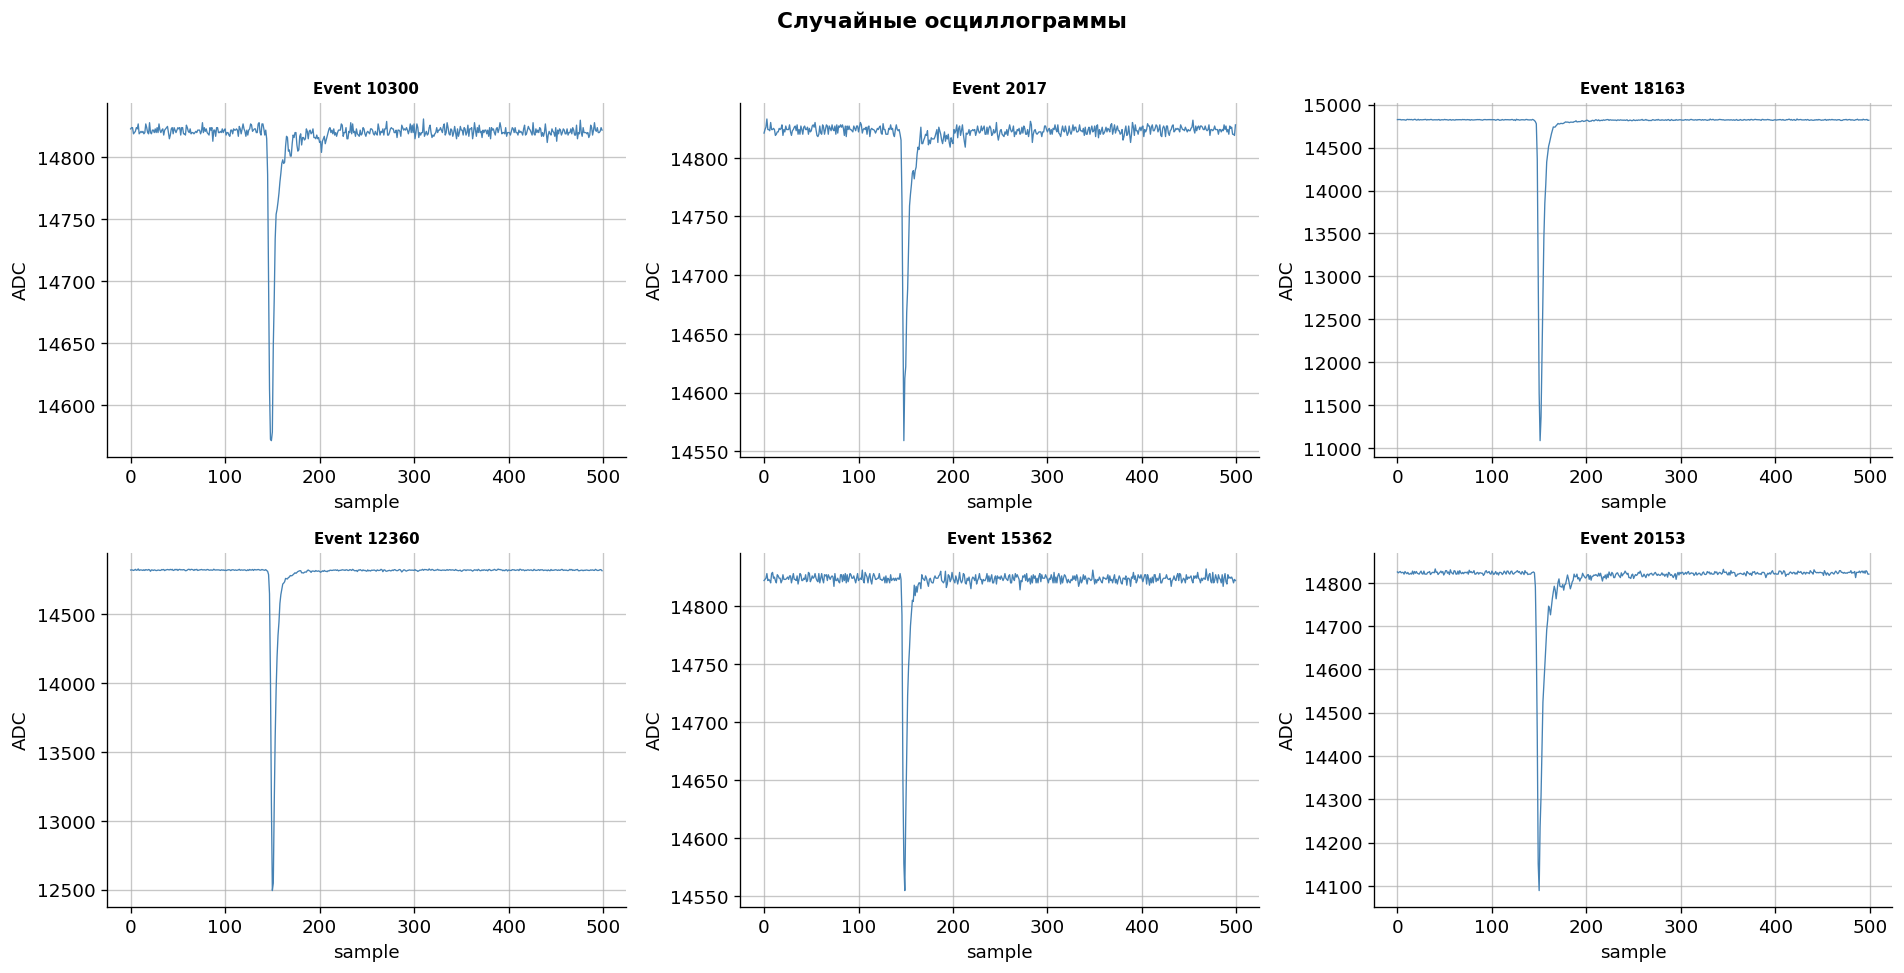

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
t = np.arange(data.shape[1])d

for ax, i in zip(axes.flat, idx):
    row_data = data.iloc[i]

    ax.plot(t, row_data, lw=0.8, color="steelblue")
    ax.set_title(f"Event {row_data.name}", fontsize=9, weight='bold')
    ax.set_xlabel("sample")
    ax.set_ylabel("ADC")
    ax.grid(alpha=0.7)

plt.suptitle("Случайные осциллограммы", fontsize=13, y=1.01, weight='bold')
plt.tight_layout()
plt.show()

### **2.2. Mean/var по времени**

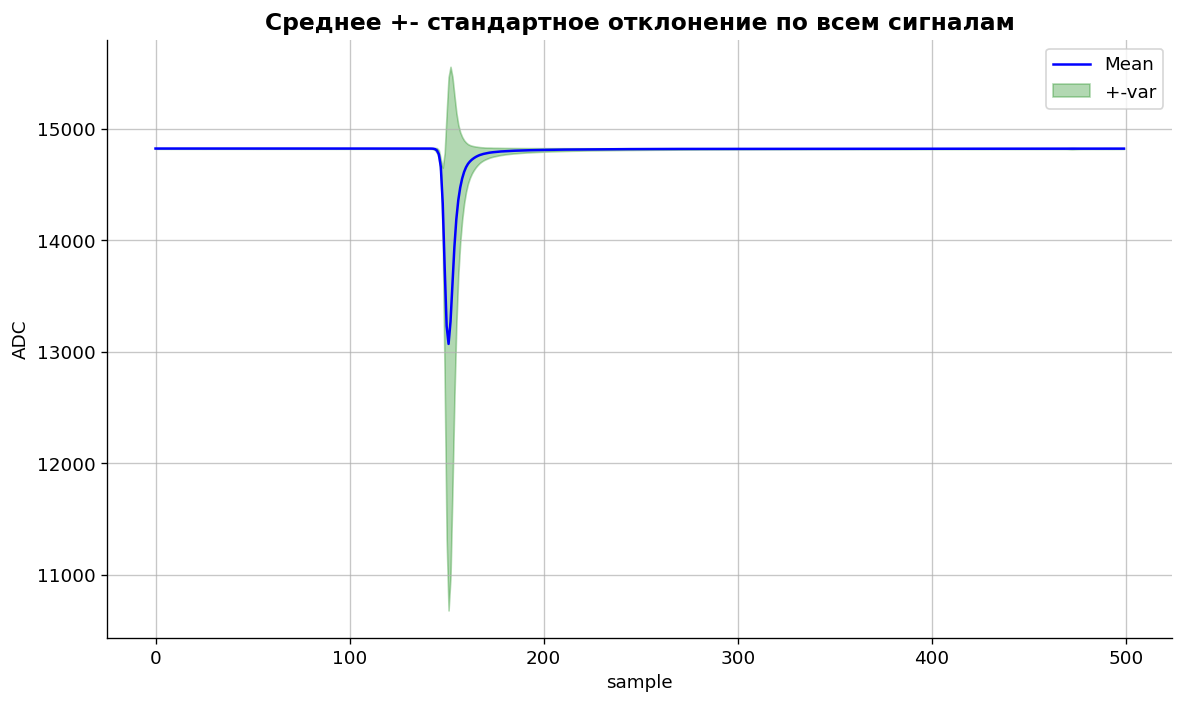

In [21]:
mean_wave = data.mean(axis=0)
std_wave  = data.std(axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, mean_wave, label="Mean", color="blue")
ax.fill_between(t, mean_wave - std_wave, mean_wave + std_wave,
                alpha=0.3, color="green", label="+-var")

ax.set_xlabel("sample"); ax.set_ylabel("ADC")
ax.set_title("Среднее +- стандартное отклонение по всем сигналам", fontsize=14, weight='bold')
ax.legend(); plt.tight_layout()
ax.grid(alpha=0.7)
plt.show()

### **2.3 Распределение амплитуд и baseline**

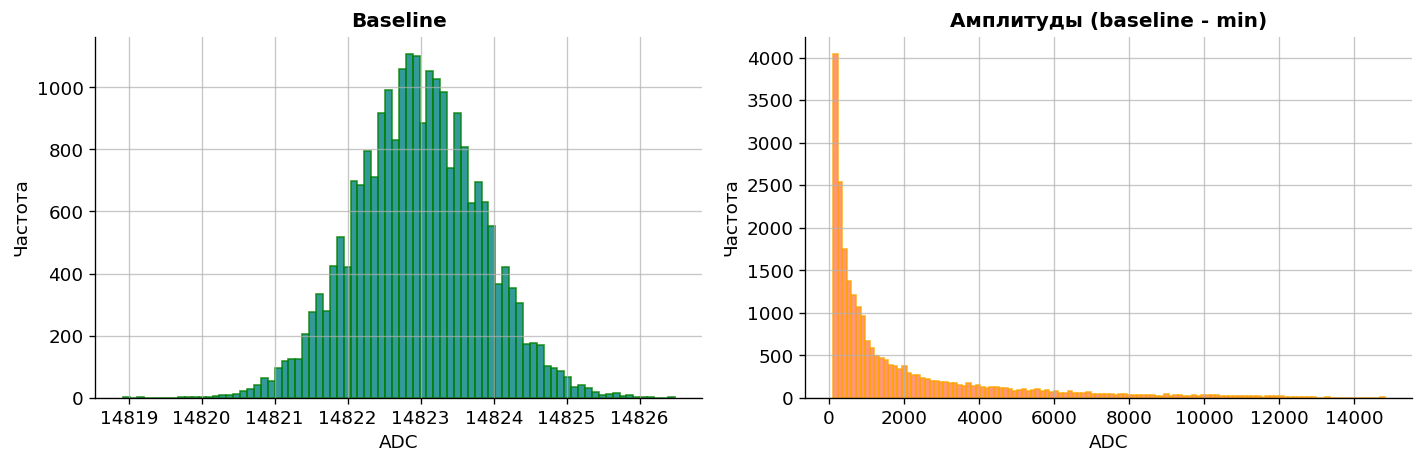

In [24]:
baseline_est = data.iloc[:, :50].mean(axis=1)
amplitude_est = baseline_est - data.iloc[:, :].min(axis=1)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(baseline_est, bins=80, color="teal", edgecolor="green", alpha=0.8)
axs[0].set_title("Baseline", fontsize=12, weight='bold')
axs[0].set_xlabel("ADC"); axs[0].set_ylabel("Частота")
axs[0].grid(alpha=0.7)

axs[1].hist(amplitude_est, bins=120, color="coral", edgecolor="orange", alpha=0.8)
axs[1].set_title("Амплитуды (baseline - min)", fontsize=12, weight='bold')
axs[1].set_xlabel("ADC"); axs[1].set_ylabel("Частота")
axs[1].grid(alpha=0.7)

plt.tight_layout()
plt.show()

---
### **3. Feature engineering**
---


Разобъем признаки на 4 группы:
- **Амплитудные**
- **Временные**
- **Интегральные**
- **Статистические**

In [25]:
def extract_features(waves, baseline_window=50, tail_start=0.3):

    if hasattr(waves, 'values'):
        waves = waves.values.astype(np.float64)
    N, T = waves.shape
    t = np.arange(T)
    feats = {}

    bl = waves[:, :baseline_window].mean(axis=1, keepdims=True)
    w  = bl - waves
    w  = np.clip(w, 0, None)

    amp = w.max(axis=1)
    feats["baseline"]  = bl.ravel()
    feats["amplitude"] = amp
    feats["amplitude_log"] = np.log1p(amp)

    tail_idx = int(T * tail_start)
    q_total = w.sum(axis=1) + 1e-9
    q_tail  = w[:, tail_idx:].sum(axis=1)
    feats["Q_total"] = q_total
    feats["Q_tail"] = q_tail
    feats["PSD"] = q_tail / q_total

    norm_w = w / (amp[:, None] + 1e-9)
    rise_10, rise_90, fall_10 = [], [], []
    fwhm_vals, t_peak_vals = [], []

    for i in range(N):
        sig = norm_w[i]
        pk  = sig.argmax()
        t_peak_vals.append(pk)

        r10 = np.where(sig[:pk] >= 0.10)[0]
        r90 = np.where(sig[:pk] >= 0.90)[0]
        rise_10.append(r10[0] if len(r10) else pk)
        rise_90.append(r90[0] if len(r90) else pk)

        f10 = np.where(sig[pk:] <= 0.10)[0]
        fall_10.append(f10[0] + pk if len(f10) else T)

        half = 0.5
        left  = np.where(sig[:pk] >= half)[0]
        right = np.where(sig[pk:] <= half)[0]
        l = left[0]  if len(left)  else pk
        r = right[0] + pk if len(right) else T
        fwhm_vals.append(r - l)

    feats["t_peak"]   = np.array(t_peak_vals)
    feats["rise_10"]  = np.array(rise_10)
    feats["rise_90"]  = np.array(rise_90)
    feats["rise_time"]= np.array(rise_90) - np.array(rise_10)
    feats["fall_time"]= np.array(fall_10) - np.array(t_peak_vals)
    feats["FWHM"]     = np.array(fwhm_vals)

    feats["skewness"]  = skew(w, axis=1)
    feats["kurt"]      = kurtosis(w, axis=1)

    diff_sign = np.diff(np.sign(w - w.mean(axis=1, keepdims=True)), axis=1)
    feats["zc_rate"]   = (diff_sign != 0).sum(axis=1) / T

    feats["rms"] = np.sqrt((w**2).mean(axis=1))

    ps = np.abs(np.fft.rfft(w, axis=1))**2
    B  = ps.shape[1]
    feats["ps_low"]  = ps[:, :B//8].sum(axis=1)
    feats["ps_mid"]  = ps[:, B//8:B//4].sum(axis=1)
    feats["ps_high"] = ps[:, B//4:].sum(axis=1)
    feats["ps_ratio"]= feats["ps_low"] / (feats["ps_high"] + 1e-9)

    feats["tail_ratio_50"]  = w[:, T//2:].sum(axis=1)  / (q_total)
    feats["tail_ratio_25"]  = w[:, T//4:].sum(axis=1)  / (q_total)
    feats["head_ratio_10"]  = w[:, :T//10].sum(axis=1) / (q_total)

    return pd.DataFrame(feats)

In [26]:
df_feat = extract_features(data)
print(f"Признаков: {df_feat.shape[1]}")
df_feat.describe().T.round(3)

Признаков: 23


,count,mean,std,min,25%,50%,75%,max
baseline,23479.0,1.482297e+04,8.560000e-01,14818.920,1.482238e+04,1.482296e+04,1.482354e+04,1.482648e+04
amplitude,23479.0,1.835105e+03,2.389301e+03,104.300,3.081600e+02,8.125400e+02,2.315050e+03,1.482484e+04
amplitude_log,23479.0,6.782000e+00,1.233000e+00,4.657,5.734000e+00,6.701000e+00,7.748000e+00,9.604000e+00
Q_total,23479.0,1.351766e+04,1.602650e+04,1043.360,2.888020e+03,6.638200e+03,1.759125e+04,1.132811e+05
Q_tail,23479.0,1.155657e+04,1.491925e+04,364.240,1.865210e+03,5.063420e+03,1.501568e+04,1.110468e+05
PSD,23479.0,7.460000e-01,1.290000e-01,0.349,6.460000e-01,7.650000e-01,8.540000e-01,9.800000e-01
t_peak,23479.0,1.496290e+02,2.490000e+00,145.000,1.490000e+02,1.500000e+02,1.510000e+02,4.720000e+02
rise_10,23479.0,1.467810e+02,1.339000e+00,142.000,1.460000e+02,1.470000e+02,1.480000e+02,1.490000e+02
rise_90,23479.0,1.492480e+02,2.487000e+00,144.000,1.480000e+02,1.490000e+02,1.500000e+02,4.720000e+02
rise_time,23479.0,2.468000e+00,2.175000e+00,1.000,2.000000e+00,2.000000e+00,3.000000e+00,3.250000e+02


### **3.1. Распределения ключевых признаков**

In [27]:
key_feats = ["PSD", "amplitude", "FWHM", "rise_time", "fall_time", "skewness", "kurt", "Q_total", "tail_ratio_50", "ps_ratio"]

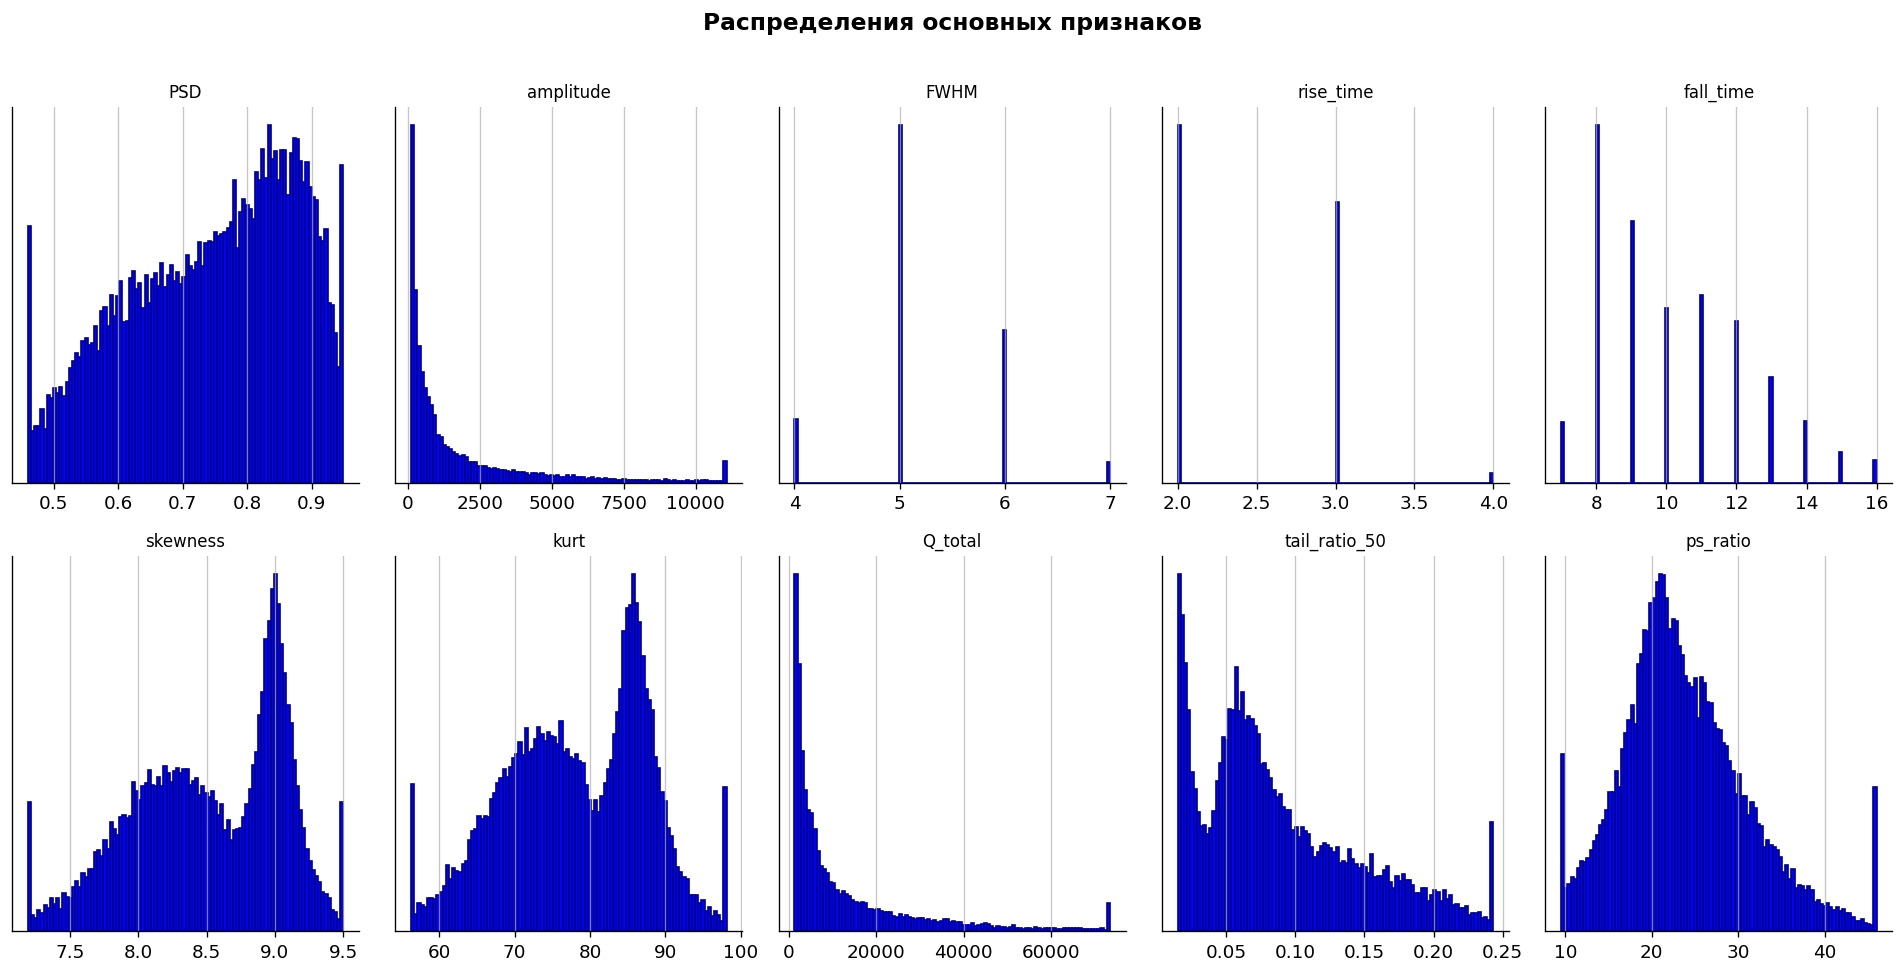

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(16, 8))

for ax, col in zip(axes.flat, key_feats):
    vals = df_feat[col].clip(df_feat[col].quantile(0.01), df_feat[col].quantile(0.99))
    ax.hist(vals, bins=100, color="blue", edgecolor="darkblue")
    ax.set_title(col, fontsize=10)
    ax.set_yticks([])
    ax.grid(alpha=0.7)

plt.suptitle("Распределения основных признаков", fontsize=14, y=1.01, weight='bold')

plt.tight_layout()
plt.show()

### **3.2. Корреляционная матрица**

In [29]:
corr = df_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

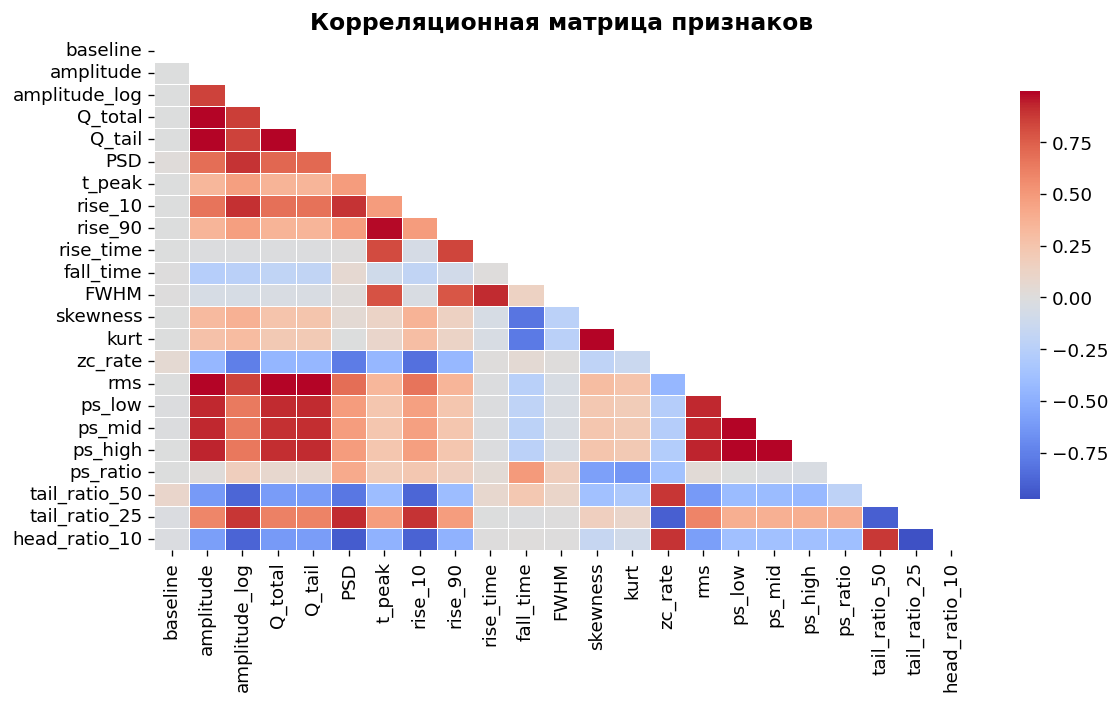

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, mask=mask, annot=False, cmap="coolwarm", center=0, linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Корреляционная матрица признаков", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

---
### **4. Предобработка**
---


**Удаляем признаки c около нулевой дисперсией**

In [38]:
selector = VarianceThreshold(threshold=1e-6)
X_var = selector.fit_transform(df_feat.fillna(0))
feat_names_sel = df_feat.columns[selector.get_support()].tolist()

print(f"Признаков после фильтрации нулевой дисперсии: {X_var.shape[1]}")

Признаков после фильтрации нулевой дисперсии: 23


**Применяем `RobustScaler`**

In [39]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_var)

---
### **5. Снижение размерности**
---
Используем **PCA** → **UMAP** для визуализации и последующей кластеризации.

PCA ускоряет UMAP и убирает шум; UMAP сохраняет локальную топологию лучше, чем t-SNE.


**Используем PCA**

In [40]:
pca = PCA(n_components=20, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

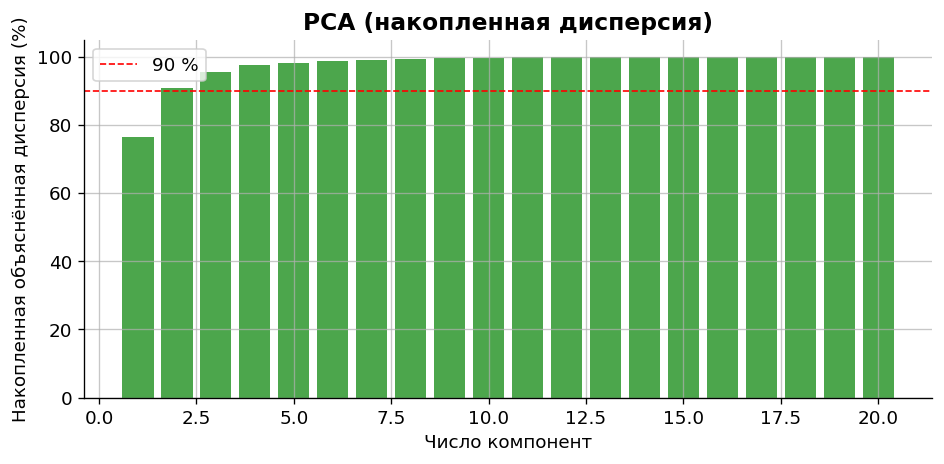

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))

ev = pca.explained_variance_ratio_
ax.bar(range(1, len(ev)+1), np.cumsum(ev)*100, color="green", alpha=0.7)
ax.axhline(90, ls="--", color="red", lw=1, label="90 %")

ax.set_title("PCA (накопленная дисперсия)", fontsize=14, weight='bold')
ax.set_xlabel("Число компонент")
ax.set_ylabel("Накопленная объяснённая дисперсия (%)")

ax.legend()
ax.grid(alpha=0.7)

plt.tight_layout()
plt.show()

In [45]:
n_comp_90 = int(np.argmax(np.cumsum(ev) >= 0.90)) + 1
print(f"Компонент для 90% дисперсии: {n_comp_90}")

Компонент для 90% дисперсии: 2


**UMAP**

In [49]:
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric="euclidean", random_state=SEED, verbose=False)
X_umap = reducer.fit_transform(X_pca)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


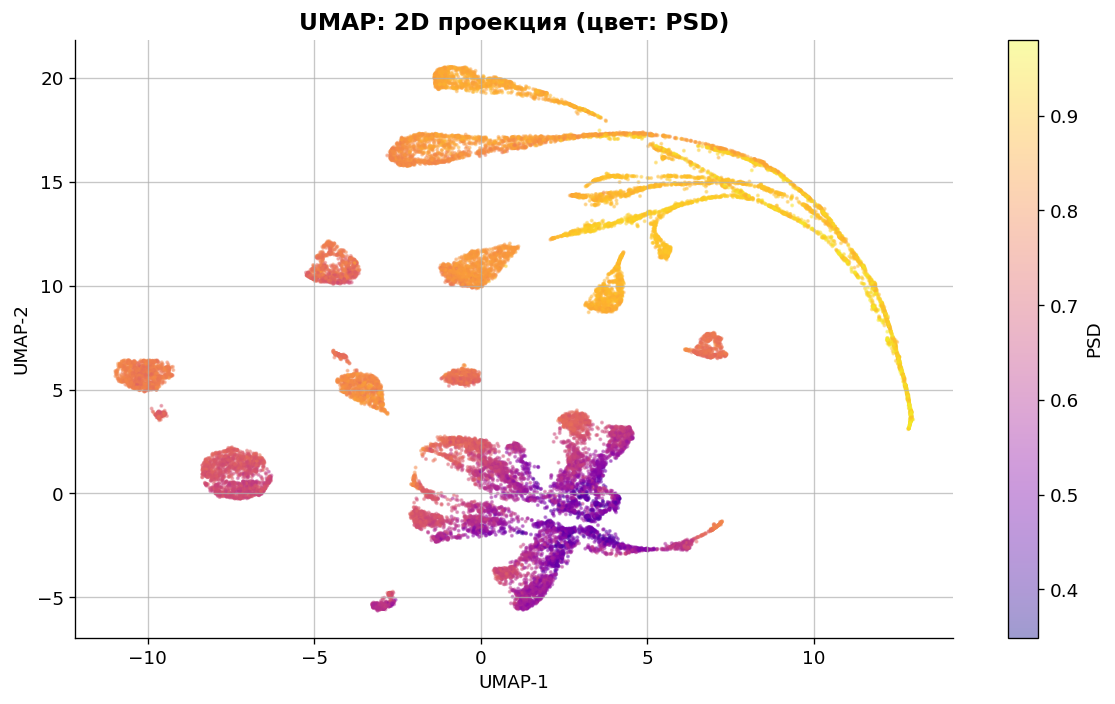

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], s=2, alpha=0.4, c=df_feat["PSD"], cmap="plasma")
plt.colorbar(sc, ax=ax, label="PSD")

ax.set_title("UMAP: 2D проекция (цвет: PSD)", fontsize=14, weight='bold')
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

ax.grid(alpha=0.7)

plt.tight_layout()
plt.show()

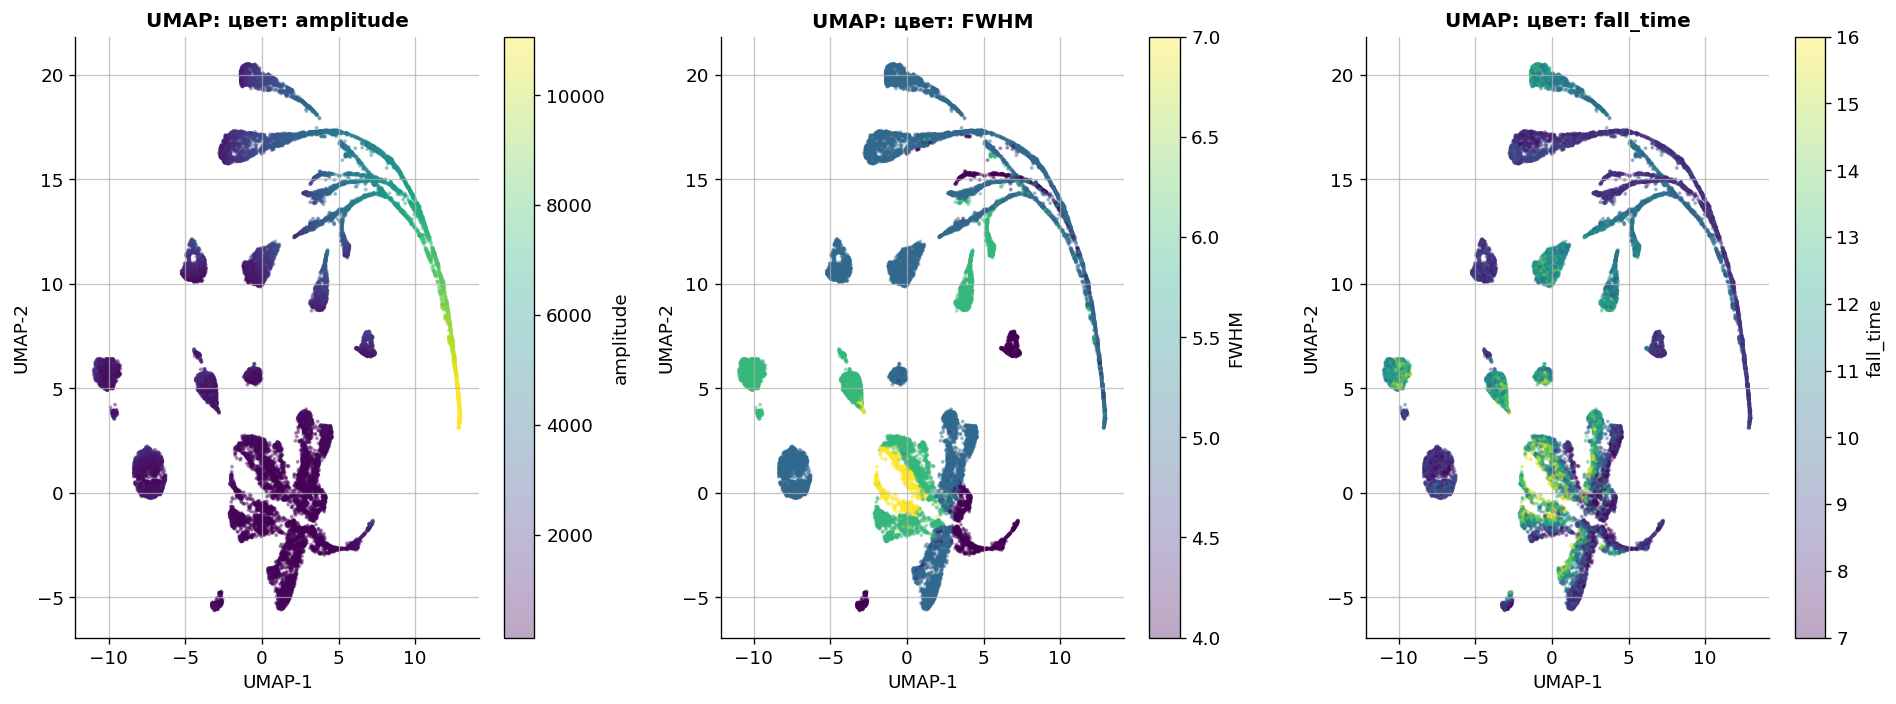

In [52]:
fig, axs = plt.subplots(1, 3, figsize=(16, 6))

for ax, col in zip(axs, ["amplitude", "FWHM", "fall_time"]):
    v = df_feat[col]
    v_clip = v.clip(v.quantile(0.01), v.quantile(0.99))
    sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], s=2, alpha=0.35, c=v_clip, cmap="viridis")
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_title(f"UMAP: цвет: {col}", fontsize=12, weight='bold')
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

    ax.grid(alpha=0.7)

plt.tight_layout()
plt.show()

---
### **6. Подбор кол-ва кластеров**
---

Основные метрики, котоыре будем использовать:
- **Silhouette** - чем выше, тем лучше
- **Calinski–Harabasz** - чем выше, тем лучше
- **Davies–Bouldin** - чем ниже, тем лучше

In [58]:
ks = range(2, 9)
sil, ch, db = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_umap)
    sil.append(silhouette_score(X_umap, labels, sample_size=5000, random_state=SEED))
    ch.append(calinski_harabasz_score(X_umap, labels))
    db.append(davies_bouldin_score(X_umap, labels))

**Визуализация**

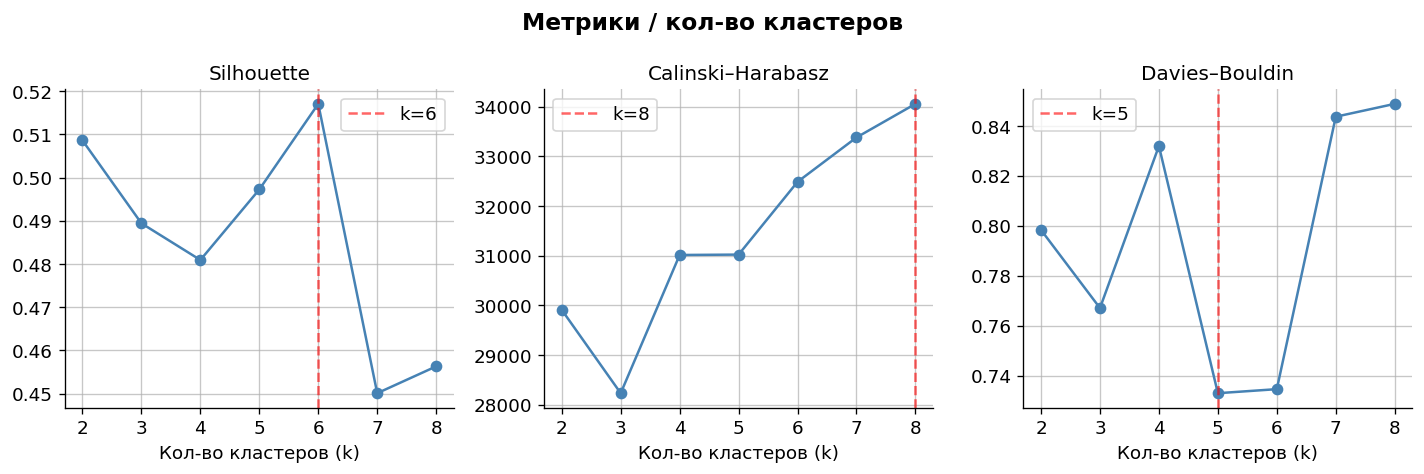

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, vals, name, better in zip(axes, [sil, ch, db], ["Silhouette", "Calinski–Harabasz", "Davies–Bouldin"], ["max", "max", "min"]):
    ax.plot(list(ks), vals, marker="o", color="steelblue")
    best_k = list(ks)[np.argmax(vals) if better == "max" else np.argmin(vals)]
    ax.axvline(best_k, ls="--", color="red", alpha=0.6, label=f"k={best_k}")

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Кол-во кластеров (k)")

    ax.grid(alpha=0.7)
    ax.legend()
    ax.set_xticks(list(ks))

plt.suptitle("Метрики / кол-во кластеров", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [55]:
print(pd.DataFrame({"k": list(ks), "Silhouette": sil, "Calinski-Harabasz": ch, "Davies-Bouldin": db}).round(4))

   k  Silhouette  Calinski-Harabasz  Davies-Bouldin
0  2      0.5086       29911.699219          0.7983
1  3      0.4894       28234.898438          0.7670
2  4      0.4809       31015.570312          0.8320
3  5      0.4973       31023.474609          0.7329
4  6      0.5171       32487.207031          0.7346
5  7      0.4501       33380.152344          0.8437
6  8      0.4563       34055.863281          0.8489


---
### **7. Обучение моделей кластеризации**
---


Сравним 4 алгоритма:

| Модель | Идея | Особенности |
|--------|------|-------------|
| **K-Means** | Минимизация инерции | Базовый, быстрый, предполагает сферические кластеры |
| **Gaussian Mixture Model** | Вероятностная мягкая кластеризация | Учитывает форму кластера, даёт вероятности принадлежности |
| **HDBSCAN** | Density-based иерархический | Автоматически выделяет шум как отдельный класс - идеально для Кластера 2 |
| **Agglomerative** | Иерархическая (Ward linkage) | Не требует числа кластеров заранее (но мы зададим k=3) |

### **7.1. Обучение**

In [64]:
K = 3

**1. K-Means**

In [65]:
km = KMeans(n_clusters=K, random_state=SEED, n_init=20, max_iter=500)
lbl_km = km.fit_predict(X_umap)

**2. GMM**

In [66]:
gmm = GaussianMixture(n_components=K, covariance_type="full", random_state=SEED, max_iter=300, n_init=5)
gmm.fit(X_umap)
lbl_gmm = gmm.predict(X_umap)
prob_gmm = gmm.predict_proba(X_umap)

**3. HDBSCAN**

In [67]:
hdb = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=30,
    cluster_selection_epsilon=0.0,
    prediction_data=True
)
lbl_hdb_raw = hdb.fit_predict(X_umap)

unique_hdb = [c for c in np.unique(lbl_hdb_raw) if c != -1]
sizes = {c: (lbl_hdb_raw == c).sum() for c in unique_hdb}
sorted_hdb = sorted(sizes, key=sizes.get, reverse=True)

remap = {}

for new_id, old_id in enumerate(sorted_hdb[:2]):
    remap[old_id] = new_id

lbl_hdb = np.where(lbl_hdb_raw == -1, 2, np.vectorize(lambda x: remap.get(x, 2))(lbl_hdb_raw))

print(f"HDBSCAN: {np.unique(lbl_hdb_raw, return_counts=True)}")

HDBSCAN: (array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), array([   3,  444,  778, 1568, 1194,  866, 1190,  308, 8390,  529,  977,
       1133, 6099]))


**4. Agglomerative**

In [68]:
agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
lbl_agg = agg.fit_predict(X_umap)

### **7.2. Визуализация в UMAP-пространстве**

In [70]:
models = [
    ("K-Means", lbl_km),
    ("GMM", lbl_gmm),
    ("Agglomerative", lbl_agg),
    ("HDBSCAN", lbl_hdb),
]

palette = ["#E63946", "#2A9D8F", "#F4A261", "#457B9D"]
n_mod = len(models)

**Визуализация**

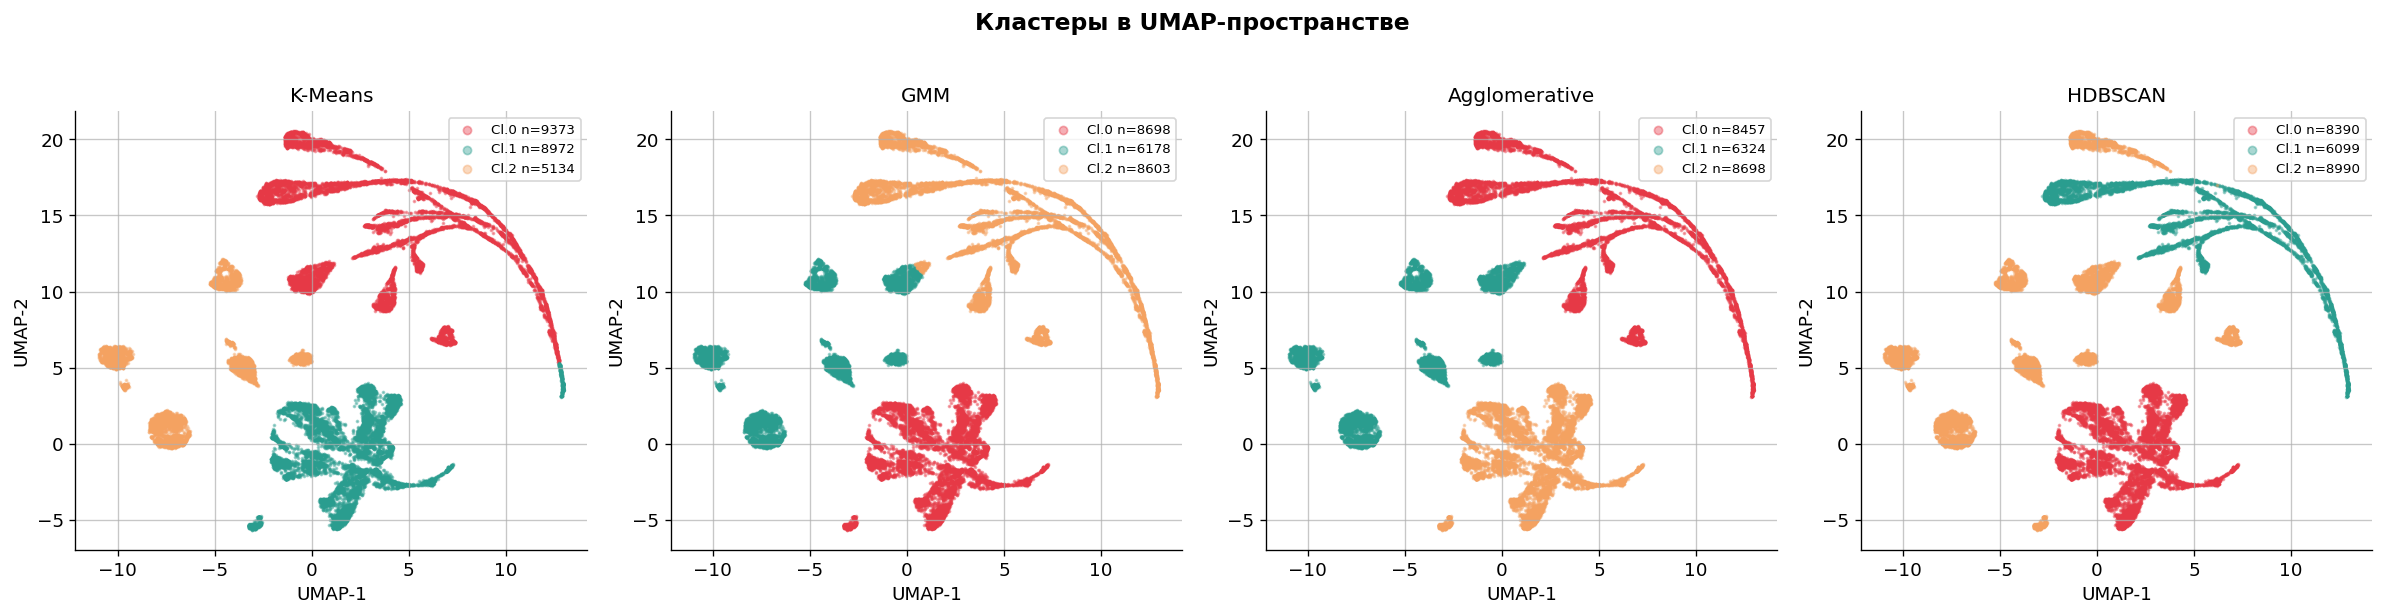

In [71]:
fig, axes = plt.subplots(1, n_mod, figsize=(5*n_mod, 5))

if n_mod == 1: axes = [axes]

for ax, (name, lbl) in zip(axes, models):
    for c in range(3):
        mask = lbl == c
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1], s=1.5, alpha=0.4, color=palette[c], label=f"Cl.{c} n={mask.sum()}")

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.grid(alpha=0.7)
    ax.legend(markerscale=4, fontsize=8)

plt.suptitle("Кластеры в UMAP-пространстве", fontsize=14, y=1.02, weight='bold')

plt.tight_layout()
plt.show()

---
### **8. Сравнение моделей по метрикам**
---

In [72]:
rows = []

for name, lbl in models:
    if len(np.unique(lbl)) < 2:
        continue
    rows.append({
        "Model": name,
        "Silhouette": round(silhouette_score(X_umap, lbl, sample_size=5000, random_state=SEED), 4),
        "Calinski-Harabasz": round(calinski_harabasz_score(X_umap, lbl), 2),
        "Davies-Bouldin": round(davies_bouldin_score(X_umap, lbl), 4),
        "n_cl0": int((lbl==0).sum()),
        "n_cl1": int((lbl==1).sum()),
        "n_cl2": int((lbl==2).sum()),
    })

metrics_df = pd.DataFrame(rows).set_index("Model")

print(metrics_df.to_string())

               Silhouette  Calinski-Harabasz  Davies-Bouldin  n_cl0  n_cl1  n_cl2
Model                                                                            
K-Means            0.4894       28234.900391          0.7670   9373   8972   5134
GMM                0.4668       25946.539062          0.8361   8698   6178   8603
Agglomerative      0.4619       25501.460938          0.8462   8457   6324   8698
HDBSCAN            0.3491       14678.379883          1.1080   8390   6099   8990


### **8.1. Физическая интерпретация: PSD по кластерам**

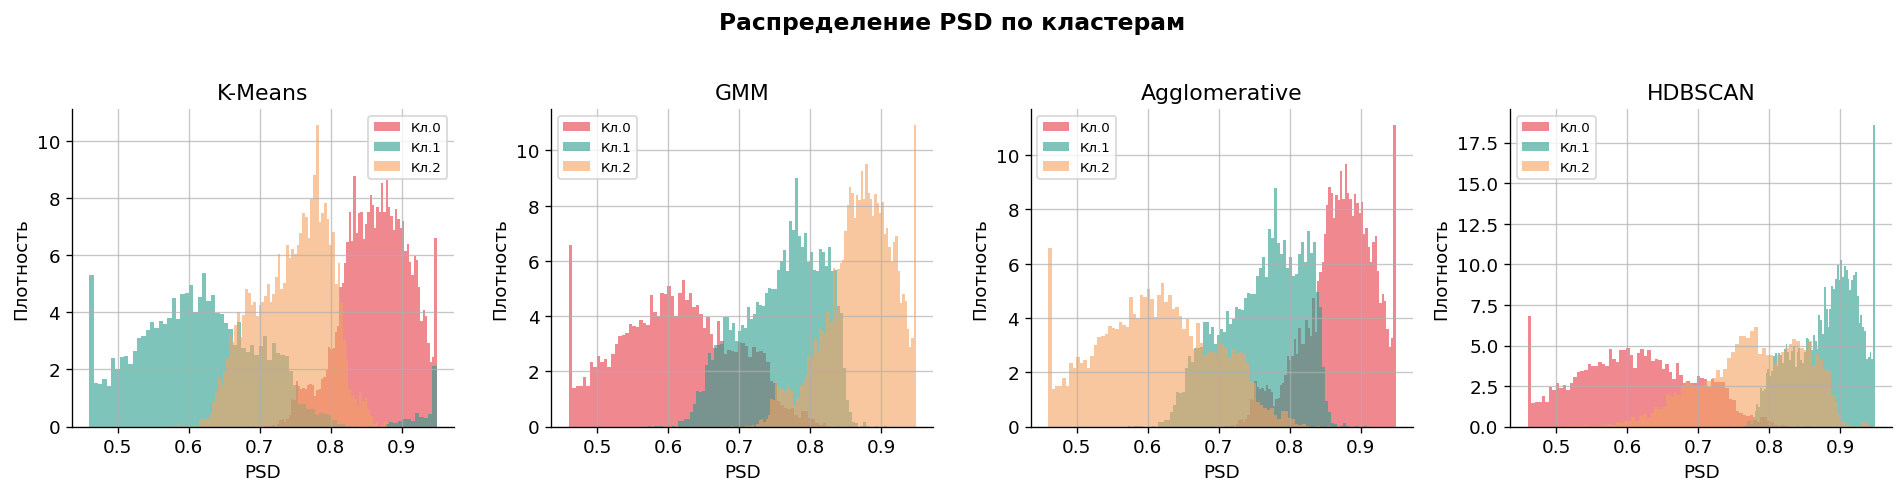

In [74]:
fig, axes = plt.subplots(1, n_mod, figsize=(4*n_mod, 4), sharey=False)

if n_mod == 1: axes = [axes]

psd_vals = df_feat["PSD"].values
psd_clip  = np.clip(psd_vals, np.percentile(psd_vals, 1), np.percentile(psd_vals, 99))

for ax, (name, lbl) in zip(axes, models):
    for c in range(3):
        mask = lbl == c
        ax.hist(psd_clip[mask], bins=80, alpha=0.6, color=palette[c], label=f"Кл.{c}", density=True)
    ax.set_title(name)
    ax.set_xlabel("PSD")
    ax.set_ylabel("Плотность")

    ax.legend(fontsize=8)
    ax.grid(alpha=0.7)

plt.suptitle("Распределение PSD по кластерам", fontsize=14, y=1.02, weight='bold')

plt.tight_layout()
plt.show()

### **8.2. Средние осциллограммы по кластерам**

In [75]:
t = np.arange(waves.shape[1])
palette_dark = ["#C0392B", "#1A7A6E", "#D4810C"]

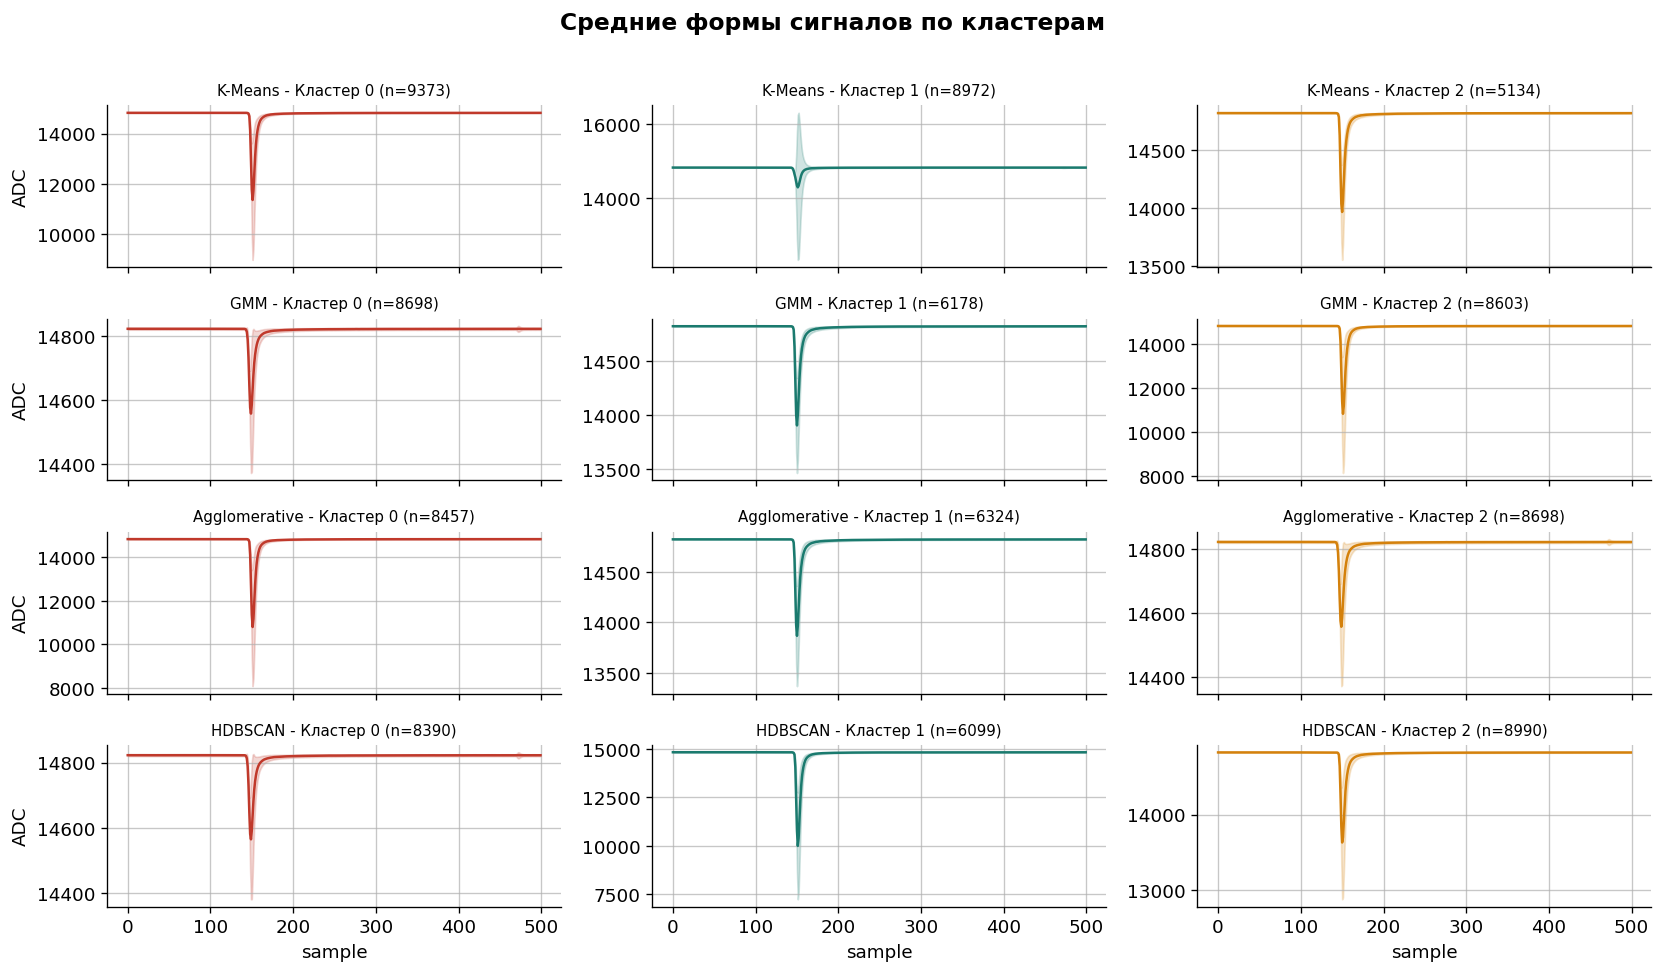

In [77]:
fig, axes = plt.subplots(n_mod, 3, figsize=(14, 2*n_mod), sharex=True)

for row, (name, lbl) in enumerate(models):
    for c in range(3):
        ax = axes[row, c] if n_mod > 1 else axes[c]
        mask = lbl == c
        mean_w = waves[mask].mean(axis=0)
        std_w  = waves[mask].std(axis=0)

        ax.plot(t, mean_w, color=palette_dark[c], lw=1.5)
        ax.fill_between(t, mean_w-std_w, mean_w+std_w, alpha=0.2, color=palette_dark[c])
        ax.set_title(f"{name} - Кластер {c} (n={mask.sum()})", fontsize=9)

        ax.grid(alpha=0.7)

        if c == 0:
          ax.set_ylabel("ADC")

        if row == n_mod-1:
          ax.set_xlabel("sample")

plt.suptitle("Средние формы сигналов по кластерам", fontsize=14, y=1.01, weight='bold')

plt.tight_layout()
plt.show()

### **8.3. Box-plots ключевых признаков по кластерам для лучшей модели (KMeans)**

In [79]:
BEST_MODEL_LABELS = lbl_km
BEST_MODEL_NAME   = "KMeans"

df_plot = df_feat[["PSD", "amplitude", "FWHM", "rise_time", "fall_time"]].copy()
df_plot["cluster"] = BEST_MODEL_LABELS
df_long = df_plot.melt(id_vars="cluster", var_name="feature", value_name="value")

**Визуализация**

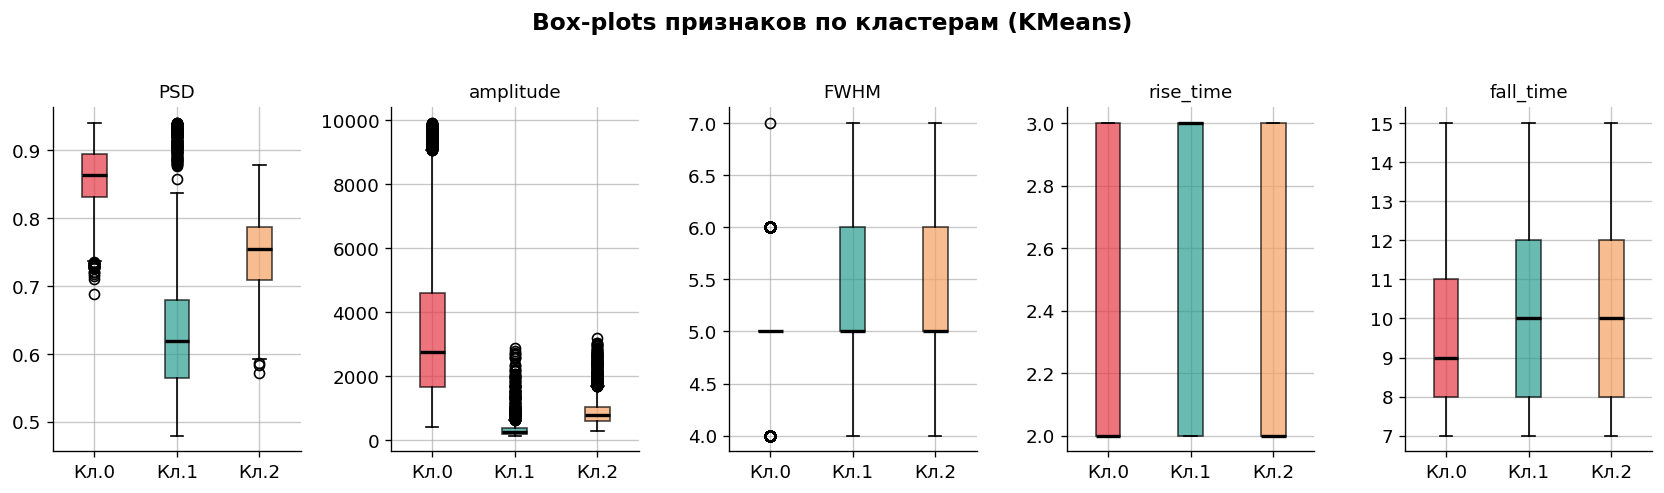

In [81]:
fig, axes = plt.subplots(1, 5, figsize=(14, 4))

for ax, feat in zip(axes, ["PSD", "amplitude", "FWHM", "rise_time", "fall_time"]):
    sub = df_long[df_long["feature"] == feat]
    sub = sub[sub["value"].between(sub["value"].quantile(0.02), sub["value"].quantile(0.98))]
    groups = [sub[sub["cluster"] == c]["value"].values for c in range(3)]

    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops={"color": "black", "lw": 2})

    for patch, color in zip(bp["boxes"], palette[:3]):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    ax.set_title(feat, fontsize=11)
    ax.set_xticklabels([f"Кл.{c}" for c in range(3)])
    ax.grid(alpha=0.7)

plt.suptitle(f"Box-plots признаков по кластерам ({BEST_MODEL_NAME})", fontsize=14, y=1.02, weight='bold')

plt.tight_layout()
plt.show()

---
### **9. Подбор гиперпараметров**
---


**Подбор гиперпараметров для кандидата в финалисты: KMeans**

In [83]:
sil_km = []
for n_init in [5, 10, 15, 20, 30]:
    km_t = KMeans(n_clusters=3, random_state=SEED, n_init=n_init)
    l = km_t.fit_predict(X_umap)
    sil_km.append((n_init, silhouette_score(X_umap, l, sample_size=5000, random_state=SEED)))

print("KMeans n_init / Silhouette:")
for ni, s in sil_km:
  print(f"  n_init={ni}: {s:.4f}")

KMeans n_init / Silhouette:
  n_init=5: 0.4894
  n_init=10: 0.4894
  n_init=15: 0.4894
  n_init=20: 0.4894
  n_init=30: 0.4894


---
### **10. Выбор лучшей модели / интерпретация**
---

Посмотрим на пункт 8 и PDS-распределения.

**Критерии выбора:**
1. Silhouette score - компактность и разделённость кластеров
2. Calinski–Harabasz - межкластерная vs внутрикластерная дисперсия
3. Физический смысл: PSD-распределения должны иметь разные пики
4. Размер аномального кластера (Класс 2) не должен быть тривиальным

По итогу я выбрал модель **KMeans** как лучшую по метрикам и остальным пунктам.

In [85]:
KMeans_final = KMeans(n_clusters=3, random_state=SEED, n_init='auto', max_iter=500)

KMeans_final.fit(X_umap)
lbl_final_raw = KMeans_final.predict(X_umap)

In [88]:
sorted_by_psd = sorted(mean_psd_per_cluster, key=mean_psd_per_cluster.get)
psd_remap = {sorted_by_psd[0]: 0, sorted_by_psd[2]: 1, sorted_by_psd[1]: 2}
lbl_kmeans  = np.vectorize(psd_remap.get)(lbl_final_raw).copy()

print("\nKMeans без порога (маппинг по PSD):")
for c in range(3):
    print(f"  Кластер {c}: {(lbl_kmeans == c).sum()} сигналов")


KMeans без порога (маппинг по PSD):
  Кластер 0: 8971 сигналов
  Кластер 1: 9374 сигналов
  Кластер 2: 5134 сигналов


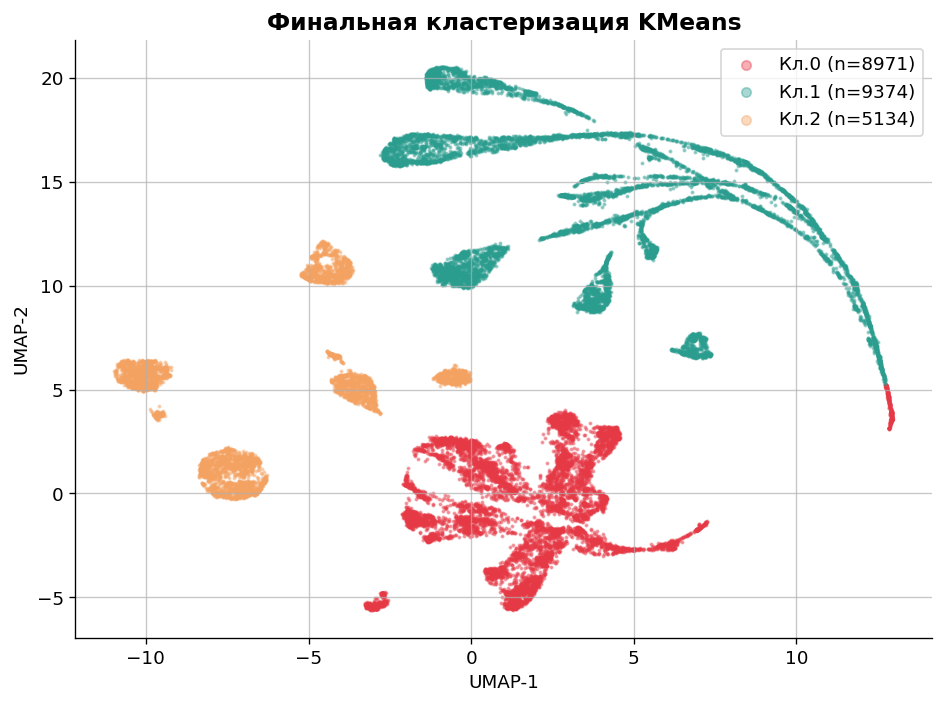

In [101]:
fig, axes = plt.subplots(figsize=(8, 6))

# UMAP с финальными метками
for c in range(3):
    mask = lbl_kmeans == c
    axes.scatter(X_umap[mask, 0], X_umap[mask, 1], s=2, alpha=0.4, color=palette[c], label=f"Кл.{c} (n={mask.sum()})")

axes.set_title("Финальная кластеризация KMeans", fontsize=14, weight='bold')
axes.set_xlabel("UMAP-1")
axes.set_ylabel("UMAP-2")

axes.grid(alpha=0.7)
axes.legend(markerscale=4)

plt.tight_layout()
plt.show()

---
### **11. Сабмиты**
---


**Выгружаем submission**

In [102]:
def relabel_sequential(labels):
    mapping, new_id = {}, 0
    result = np.empty_like(labels)
    for i, lbl in enumerate(labels):
        if lbl not in mapping:
            mapping[lbl] = new_id
            new_id += 1
        result[i] = mapping[lbl]
    return result

In [103]:
def save_submit(labels, name):
    labels_seq = relabel_sequential(np.array(labels))
    df_sub = pd.DataFrame({"index": range(len(labels_seq)), "cluster": labels_seq})
    path = f"{SUBMIT_DIR}/{name}.csv"
    df_sub.to_csv(path, index=False)
    counts = dict(pd.Series(labels_seq).value_counts().sort_index())
    print(f" {path}  |  {counts}")
    return path


In [104]:
save_submit(lbl_kmeans, "submission_kmeans")

 submissions/submission_kmeans.csv  |  {0: np.int64(8971), 1: np.int64(9374), 2: np.int64(5134)}


'submissions/submission_kmeans.csv'

**12. Результаты**

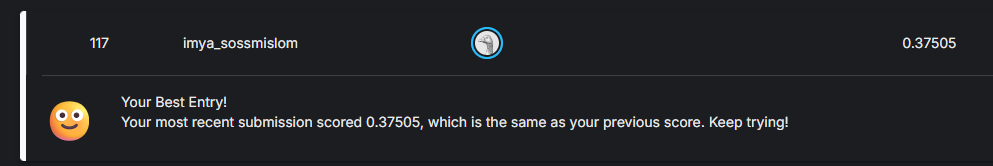